In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

df.head()

,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [2]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (100, 5)
Target Shape: (100,)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (100, 5)


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Features:", X.shape[1])
print("PCA Components:", X_pca.shape[1])
print("PCA Shape:", X_pca.shape)

Original Features: 5
PCA Components: 2
PCA Shape: (100, 2)


In [5]:
explained_variance = pca.explained_variance_ratio_

print("PC1 Variance:", round(explained_variance[0], 4))
print("PC2 Variance:", round(explained_variance[1], 4))
print("Total Variance Retained:", round(explained_variance.sum(), 4))

PC1 Variance: 0.2508
PC2 Variance: 0.2178
Total Variance Retained: 0.4686


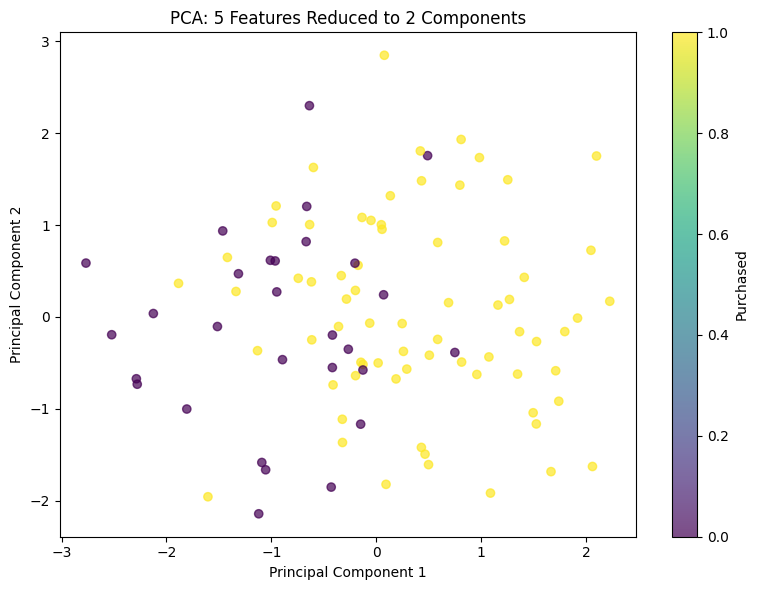

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: 5 Features Reduced to 2 Components")
plt.colorbar(label="Purchased")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_before = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)

accuracy_before = accuracy_score(y_test, pred_before)

print("Accuracy BEFORE PCA:", round(accuracy_before, 4))

Accuracy BEFORE PCA: 1.0


In [8]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_after = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_after.fit(X_train_pca, y_train_pca)

pred_after = model_after.predict(X_test_pca)

accuracy_after = accuracy_score(
    y_test_pca,
    pred_after
)

print("Accuracy AFTER PCA:", round(accuracy_after, 4))

Accuracy AFTER PCA: 0.65


In [9]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Random Forest"],
    "Feature Representation": ["Original Features", "PCA Components"],
    "Number of Features": [5, 2],
    "Accuracy": [accuracy_before, accuracy_after]
})

comparison


,Model,Feature Representation,Number of Features,Accuracy
0,Random Forest,Original Features,5,1.00
1,Random Forest,PCA Components,2,0.65


In [10]:
comparison.to_csv("day24_pca_performance_comparison.csv", index=False)

print("PCA performance comparison report saved successfully!")

PCA performance comparison report saved successfully!


In [11]:
variance_report = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained Variance Ratio": explained_variance
})

variance_report["Explained Variance (%)"] = (
    variance_report["Explained Variance Ratio"] * 100
).round(2)

variance_report.loc[len(variance_report)] = [
    "Total",
    explained_variance.sum(),
    round(explained_variance.sum() * 100, 2)
]

variance_report

,Component,Explained Variance Ratio,Explained Variance (%)
0,PC1,0.250798,25.08
1,PC2,0.217848,21.78
2,Total,0.468645,46.86


In [12]:
variance_report.to_csv("day24_pca_variance_analysis.csv", index=False)

print("PCA variance analysis report saved successfully!")

PCA variance analysis report saved successfully!


In [13]:
print("Dataset Shape:", df.shape)

print("\nPCA Shape:", X_pca.shape)

print("\nExplained Variance:")
print(variance_report)

print("\nPerformance Comparison:")
print(comparison)

print("\nDay 24 files:")
print("✓ day24_pca_dimensionality_reduction.ipynb")
print("✓ day24_pca_performance_comparison.csv")
print("✓ day24_pca_variance_analysis.csv")

Dataset Shape: (100, 6)

PCA Shape: (100, 2)

Explained Variance:
  Component  Explained Variance Ratio  Explained Variance (%)
0       PC1                  0.250798                   25.08
1       PC2                  0.217848                   21.78
2     Total                  0.468645                   46.86

Performance Comparison:
           Model Feature Representation  Number of Features  Accuracy
0  Random Forest      Original Features                   5      1.00
1  Random Forest         PCA Components                   2      0.65

Day 24 files:
✓ day24_pca_dimensionality_reduction.ipynb
✓ day24_pca_performance_comparison.csv
✓ day24_pca_variance_analysis.csv
